<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/Statics%20and%20visualizarion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd



In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
df =pd.read_csv('/content/online_shopping_customer_behavior (1).csv')

In [4]:
df.head()

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
0,CUST_1,Male,40,Australia,Tablet,Clothing,87,12,8,1187
1,CUST_2,Female,38,Pakistan,Tablet,Electronics,71,22,3,153
2,CUST_3,Male,36,UK,Tablet,Clothing,59,20,8,1055
3,CUST_4,Male,36,Pakistan,Mobile,Clothing,39,18,3,991
4,CUST_5,Male,53,Canada,Desktop,Electronics,3,1,1,588


In [5]:
numeric_cols = ['age', 'time_spent_minutes', 'items_viewed',
                'items_purchased', 'total_spent_usd']

In [6]:
df_z = df.copy()
for col in numeric_cols:
    col_mean = df[col].mean()
    col_std  = df[col].std()
    df_z[f'z_{col}'] = (df[col] - col_mean) / col_std
    print(f"\n  {col}:")
    print(f"    Mean (μ)  = {col_mean:.2f}")
    print(f"    Std  (σ)  = {col_std:.2f}")


  age:
    Mean (μ)  = 41.14
    Std  (σ)  = 13.48

  time_spent_minutes:
    Mean (μ)  = 60.54
    Std  (σ)  = 34.72

  items_viewed:
    Mean (μ)  = 24.54
    Std  (σ)  = 14.04

  items_purchased:
    Mean (μ)  = 4.61
    Std  (σ)  = 2.85

  total_spent_usd:
    Mean (μ)  = 778.50
    Std  (σ)  = 434.79


In [7]:
focus_col   = 'total_spent_usd'
focus_z_col = f'z_{focus_col}'
mu    = df[focus_col].mean()
sigma = df[focus_col].std()

print(f"\n🔍 Focus column : {focus_col}")
print(f"   μ = {mu:.2f}  |  σ = {sigma:.2f}")
print(f"\n   Z-Score Formula : Z = (X − μ) / σ")
print(f"   Z-Score Formula : Z = (X − {mu:.2f}) / {sigma:.2f}")


🔍 Focus column : total_spent_usd
   μ = 778.50  |  σ = 434.79

   Z-Score Formula : Z = (X − μ) / σ
   Z-Score Formula : Z = (X − 778.50) / 434.79


In [8]:
outliers   = df_z[df_z[focus_z_col].abs() > 2]
print(f"\n⚠️  Outliers (|Z| > 2): {len(outliers)} rows "
      f"({len(outliers)/len(df)*100:.1f}% of dataset)")
print(outliers[['customer_id', focus_col, focus_z_col]].head(10).to_string(index=False))



⚠️  Outliers (|Z| > 2): 0 rows (0.0% of dataset)
Empty DataFrame
Columns: [customer_id, total_spent_usd, z_total_spent_usd]
Index: []


Text(0.5, 0.98, 'Z-Score Analysis — total_spent_usd')

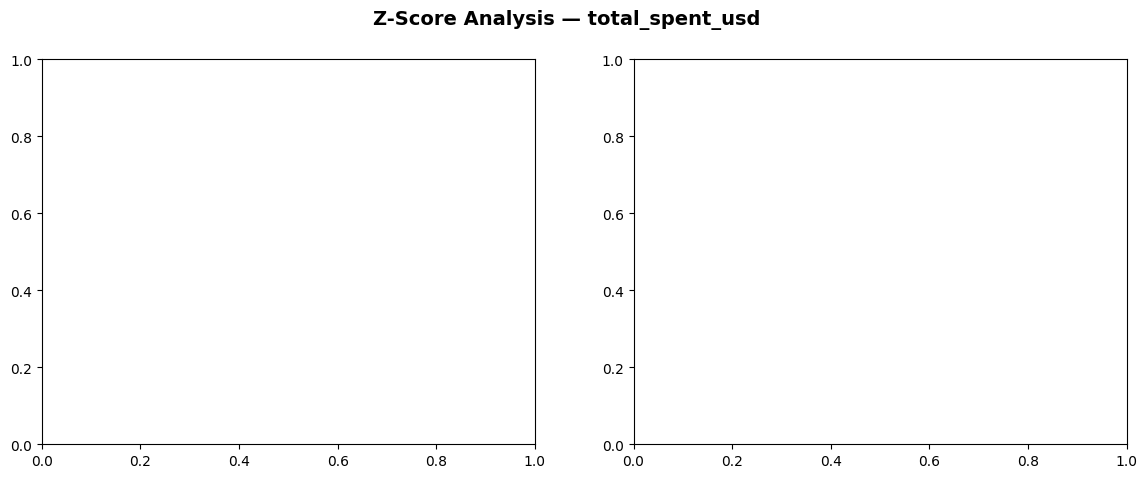

In [9]:

# ── 1d. Plot Z-Score Distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Z-Score Analysis — total_spent_usd", fontsize=14, fontweight='bold')



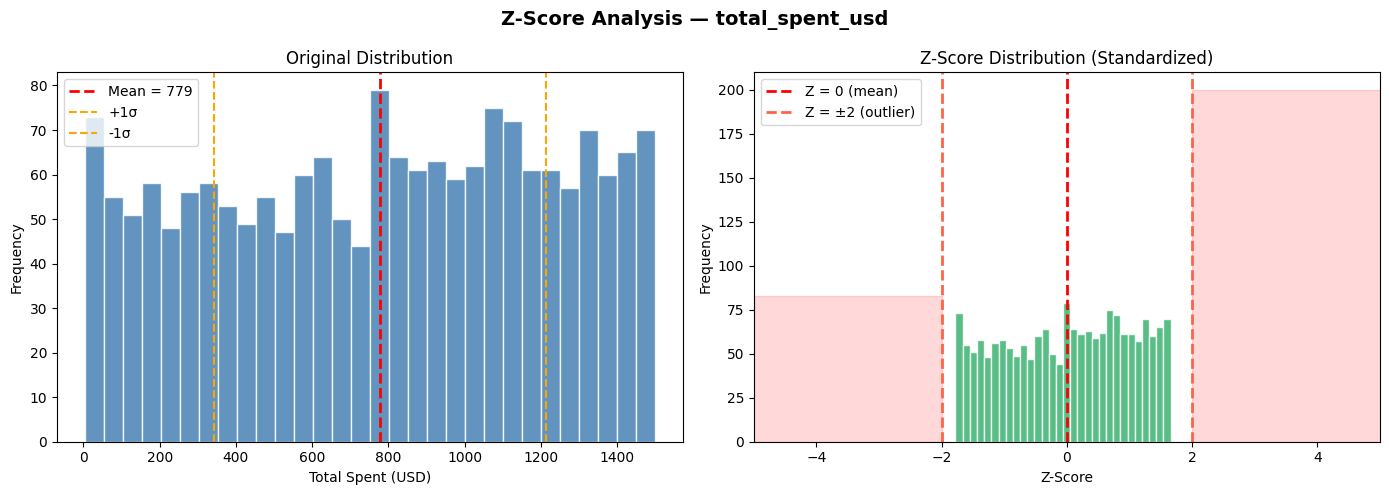

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Z-Score Analysis — total_spent_usd", fontsize=14, fontweight='bold')

# Left: Original distribution
axes[0].hist(df[focus_col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mu, color='red',    linestyle='--', linewidth=2, label=f'Mean = {mu:.0f}')
axes[0].axvline(mu + sigma, color='orange', linestyle='--', label='+1σ')
axes[0].axvline(mu - sigma, color='orange', linestyle='--', label='-1σ')
axes[0].set_title("Original Distribution")
axes[0].set_xlabel("Total Spent (USD)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Right: Z-Score distribution
z_vals = df_z[focus_z_col]
axes[1].hist(z_vals, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0,  color='red',    linestyle='--', linewidth=2, label='Z = 0 (mean)')
axes[1].axvline( 2, color='tomato', linestyle='--', linewidth=2, label='Z = ±2 (outlier)')
axes[1].axvline(-2, color='tomato', linestyle='--', linewidth=2)
# Shade outlier regions
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1]>0 else 200],
                      -5, -2, alpha=0.15, color='red')
axes[1].fill_betweenx([0, 200], 2, 5, alpha=0.15, color='red')
axes[1].set_title("Z-Score Distribution (Standardized)")
axes[1].set_xlabel("Z-Score")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(-5, 5)
axes[1].legend()

plt.tight_layout()
plt.savefig("z_score_analysis.png", dpi=150, bbox_inches='tight')
plt.show()



In [11]:

print("PART 2 — CENTRAL LIMIT THEOREM")


population   = df['total_spent_usd'].values
pop_mean     = population.mean()
pop_std      = population.std()

print(f"\n  Population Mean (μ)     = {pop_mean:.2f}")
print(f"  Population Std  (σ)     = {pop_std:.2f}")
print(f"\n  CLT States: As sample size n → ∞,")
print(f"  the distribution of sample means x̄ → Normal(μ, σ²/n)")
print(f"  Standard Error (SE) = σ / √n")


PART 2 — CENTRAL LIMIT THEOREM

  Population Mean (μ)     = 778.50
  Population Std  (σ)     = 434.67

  CLT States: As sample size n → ∞,
  the distribution of sample means x̄ → Normal(μ, σ²/n)
  Standard Error (SE) = σ / √n



  n =   5  |  SE = 194.39  |  Sample mean = 776.60  |  Sample std = 196.76

  n =  10  |  SE = 137.45  |  Sample mean = 778.06  |  Sample std = 136.18

  n =  30  |  SE = 79.36  |  Sample mean = 777.90  |  Sample std = 80.69

  n = 100  |  SE = 43.47  |  Sample mean = 781.98  |  Sample std = 44.39


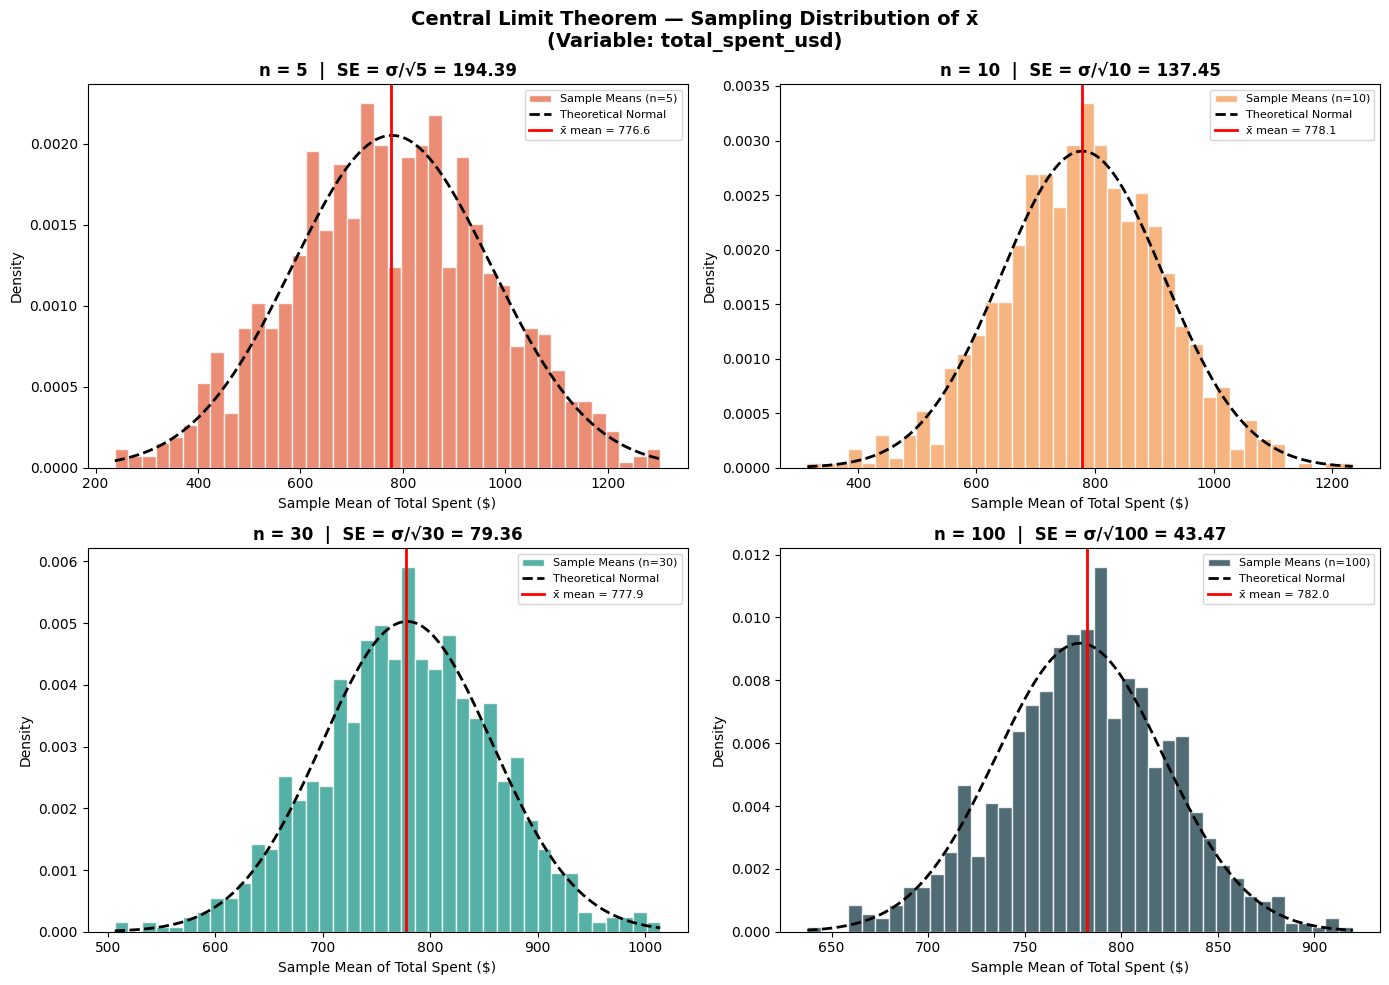

In [17]:
np.random.seed(42)
sample_sizes = [5, 10, 30, 100]
n_simulations = 1000           # draw 1000 samples for each size

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Central Limit Theorem — Sampling Distribution of x̄\n"
             "(Variable: total_spent_usd)", fontsize=14, fontweight='bold')

colors = ['#e76f51', '#f4a261', '#2a9d8f', '#264653']
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    sample_means = [
        np.random.choice(population, size=n, replace=True).mean()
        for _ in range(n_simulations)
    ]
    se = pop_std / np.sqrt(n)

    # Histogram of sample means
    axes[i].hist(sample_means, bins=40, density=True,
                 color=colors[i], edgecolor='white', alpha=0.8,
                 label=f'Sample Means (n={n})')

    # Overlay theoretical normal curve
    x_range = np.linspace(min(sample_means), max(sample_means), 300)
    normal_curve = stats.norm.pdf(x_range, pop_mean, se)
    axes[i].plot(x_range, normal_curve, 'k--', linewidth=2, label='Theoretical Normal')

    axes[i].axvline(np.mean(sample_means), color='red', linewidth=2,
                    label=f'x̄ mean = {np.mean(sample_means):.1f}')
    axes[i].set_title(f"n = {n}  |  SE = σ/√{n} = {se:.2f}", fontweight='bold')
    axes[i].set_xlabel("Sample Mean of Total Spent ($)")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

    print(f"\n  n = {n:>3}  |  SE = {se:.2f}  "
          f"|  Sample mean = {np.mean(sample_means):.2f}  "
          f"|  Sample std = {np.std(sample_means):.2f}")

plt.tight_layout()
plt.savefig("clt_analysis.png", dpi=150, bbox_inches='tight')
plt.show()



In [13]:
n_sample = 50
sample   = np.random.choice(population, size=n_sample, replace=True)
x_bar    = sample.mean()
se_50    = pop_std / np.sqrt(n_sample)
ci_95    = stats.norm.interval(0.95, loc=x_bar, scale=se_50)

print(f"\n  95% Confidence Interval (n={n_sample}):")
print(f"  x̄ = {x_bar:.2f}  ±  1.96 × {se_50:.2f}")
print(f"  CI = [{ci_95[0]:.2f},  {ci_95[1]:.2f}]")
print(f"  Interpretation: We are 95% confident the true mean")
print(f"  total spend lies between ${ci_95[0]:.2f} and ${ci_95[1]:.2f}")


  95% Confidence Interval (n=50):
  x̄ = 752.06  ±  1.96 × 61.47
  CI = [631.58,  872.54]
  Interpretation: We are 95% confident the true mean
  total spend lies between $631.58 and $872.54


In [14]:
# ── 3a. Simple Linear Regression: time_spent → total_spent ──
X_col, y_col = 'time_spent_minutes', 'total_spent_usd'

X = df[[X_col]].values        # 2D array for sklearn
y = df[y_col].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2     = r2_score(y, y_pred)
rmse   = np.sqrt(mean_squared_error(y, y_pred))
slope  = model.coef_[0]
intercept = model.intercept_

print(f"\n  Simple Linear Regression:")
print(f"  X = {X_col}  →  Y = {y_col}")
print(f"\n  Equation  : ŷ = {intercept:.4f} + {slope:.4f} · X")
print(f"  R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  RMSE      : {rmse:.2f}")
print(f"\n  Interpretation:")
print(f"  For every extra minute spent, total spend changes by ${slope:.2f}")


  Simple Linear Regression:
  X = time_spent_minutes  →  Y = total_spent_usd

  Equation  : ŷ = 773.7979 + 0.0777 · X
  R² Score  : 0.0000  (0.0% variance explained)
  RMSE      : 434.66

  Interpretation:
  For every extra minute spent, total spend changes by $0.08


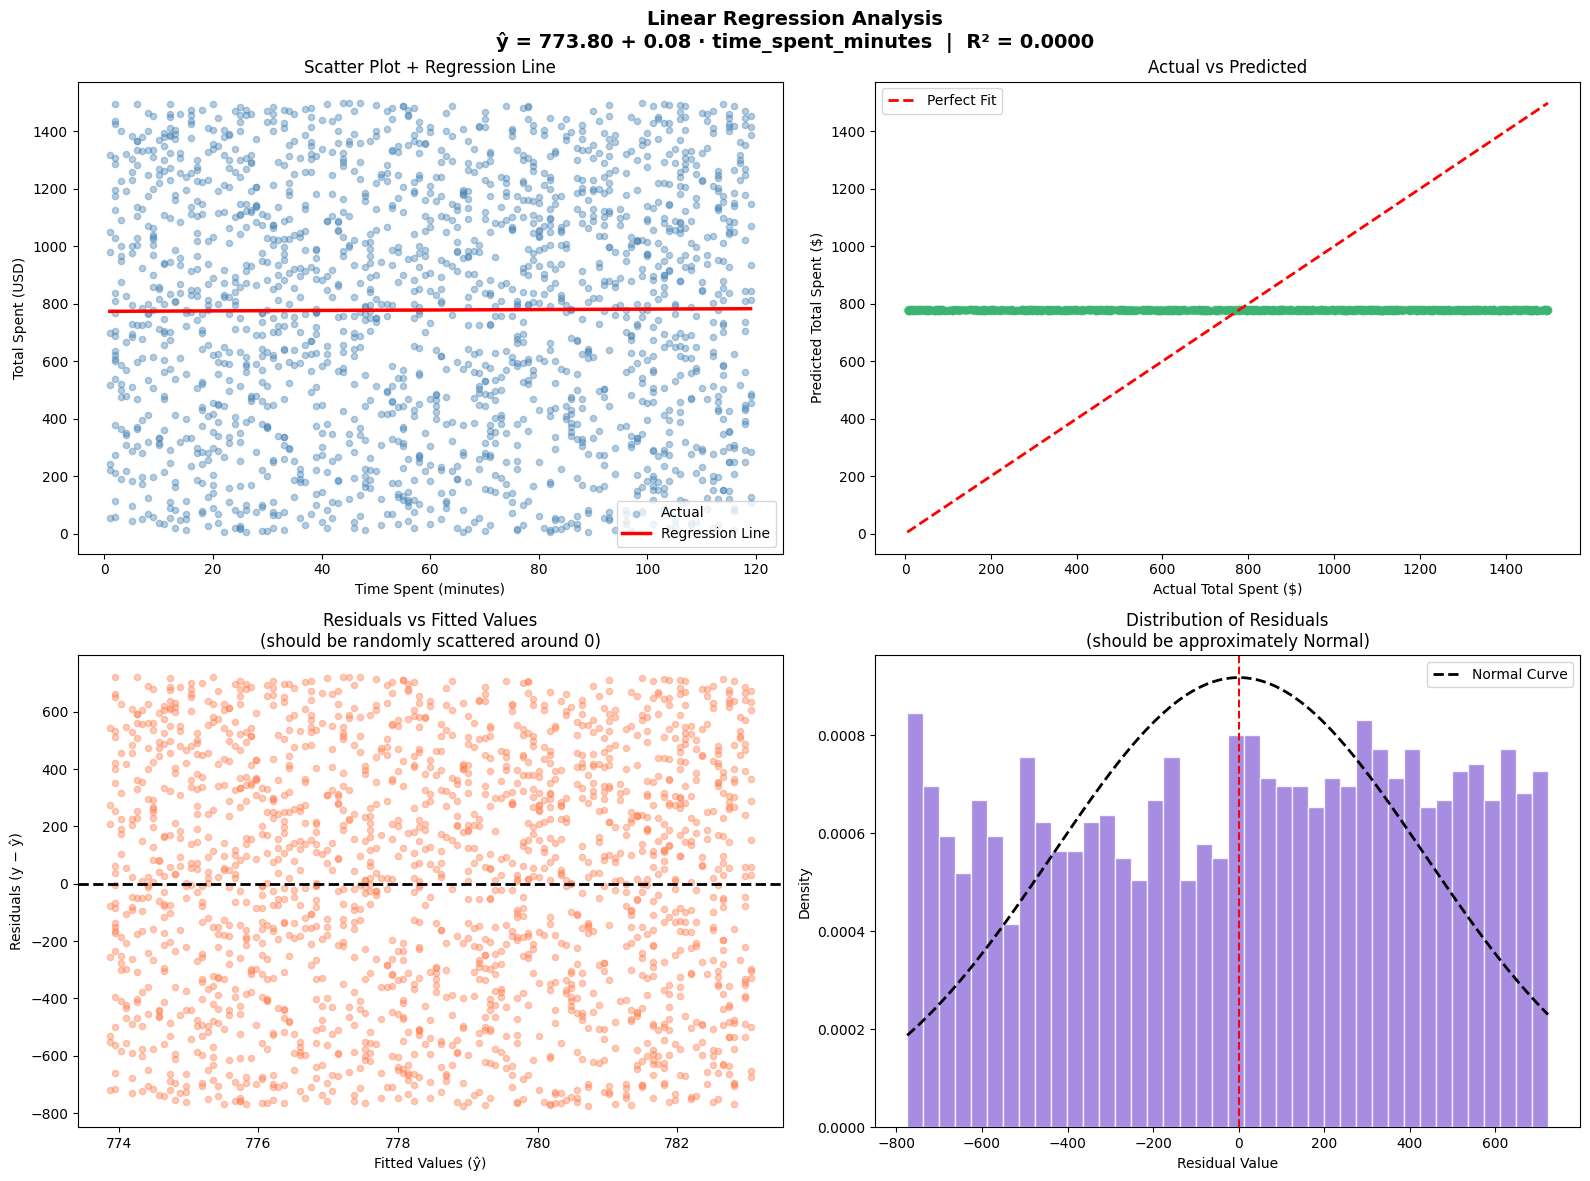

📸 Saved: regression_analysis.png


In [15]:
residuals = y - y_pred

# ── 3d. Regression Plots ─────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Linear Regression Analysis\n"
             f"ŷ = {intercept:.2f} + {slope:.2f} · time_spent_minutes  |  R² = {r2:.4f}",
             fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1: Scatter + regression line
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(df[X_col], df[y_col], alpha=0.4, s=20, color='steelblue', label='Actual')
x_line = np.linspace(df[X_col].min(), df[X_col].max(), 300).reshape(-1, 1)
y_line = model.predict(x_line)
ax1.plot(x_line, y_line, color='red', linewidth=2.5, label=f'Regression Line')
ax1.set_xlabel("Time Spent (minutes)")
ax1.set_ylabel("Total Spent (USD)")
ax1.set_title("Scatter Plot + Regression Line")
ax1.legend()

# Plot 2: Actual vs Predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y, y_pred, alpha=0.4, s=20, color='mediumseagreen')
min_val, max_val = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
ax2.set_xlabel("Actual Total Spent ($)")
ax2.set_ylabel("Predicted Total Spent ($)")
ax2.set_title("Actual vs Predicted")
ax2.legend()

# Plot 3: Residuals vs Fitted
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_pred, residuals, alpha=0.4, s=20, color='coral')
ax3.axhline(0, color='black', linewidth=2, linestyle='--')
ax3.set_xlabel("Fitted Values (ŷ)")
ax3.set_ylabel("Residuals (y − ŷ)")
ax3.set_title("Residuals vs Fitted Values\n(should be randomly scattered around 0)")

# Plot 4: Residual distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax4.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
         'k--', linewidth=2, label='Normal Curve')
ax4.axvline(0, color='red', linestyle='--')
ax4.set_xlabel("Residual Value")
ax4.set_ylabel("Density")
ax4.set_title("Distribution of Residuals\n(should be approximately Normal)")
ax4.legend()

plt.tight_layout()
plt.savefig("regression_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("📸 Saved: regression_analysis.png")
